In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoLarsCV
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoLars
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso

## 2. Data Preprocessing

In [59]:
# download orginal dataset
df=pd.read_csv("case1Data.csv")

# create vector for target variable (y)
y_class=df["y"]

# create dataframe for features, numerical and categorical (x)
data=df.drop("y",axis=1)

# only categorical features
categorical_data=data[["C_01", "C_02", "C_03", "C_04", "C_05"]]

# only numeric features
numerical_data=data.drop(columns=categorical_data.columns)

numerical_data = numerical_data.fillna(numerical_data.median(numeric_only=True))
print(numerical_data.isna().sum())

categorical_data.drop(columns="C_02", inplace=True)

categorical_data = categorical_data.fillna("missing")
print(categorical_data.isna().sum())

categorical_data = pd.get_dummies(categorical_data)
categorical_data = categorical_data.astype(int)
categorical_data.head()

categorical_data.columns = categorical_data.columns.str.replace(".0", "", regex=False)
categorical_data.head()

X = pd.concat([numerical_data, categorical_data], axis=1)
print(X.shape)
X.head()

x_01    0
x_02    0
x_03    0
x_04    0
x_05    0
       ..
x_91    0
x_92    0
x_93    0
x_94    0
x_95    0
Length: 95, dtype: int64
C_01    0
C_03    0
C_04    0
C_05    0
dtype: int64
(100, 119)


,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,C_04_73,C_04_74,C_04_75,C_04_missing,C_05_71,C_05_72,C_05_73,C_05_74,C_05_75,C_05_missing
0,6.359019,-13.367120,-2.483750,-6.641891,11.733539,-3.771067,-17.085361,22.194764,16.827888,-10.367142,...,1,0,0,0,0,0,1,0,0,0
1,3.873664,-8.470389,-3.055012,-5.793856,11.420983,1.822330,-13.694100,22.738654,20.307503,-2.859097,...,1,0,0,0,0,0,1,0,0,0
2,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,22.435510,15.963889,-3.257940,...,0,1,0,0,0,0,0,1,0,0
3,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,-5.616061,...,0,0,0,0,0,1,0,0,0,0
4,3.116458,-8.518713,-6.796050,-5.793856,7.646285,-3.118309,-13.102567,22.801217,16.680208,-3.357765,...,0,1,0,0,0,0,0,0,1,0


## 3. Lasso

In [60]:
def centerData(data):
    mu = np.mean(data,axis=0)
    data = data - mu
    return data, mu

In [61]:
X_np = X.values
y_np = y_class.values

# numerical columns to standardize
num_cols = numerical_data.columns
num_idx = [X.columns.get_loc(c) for c in num_cols]

# for the repetitions of the outer cv
repetitions_rmse = []

# save hyperparameters from model selection
best_alphas = []

# residual analysis
y_cv_true = []
y_cv_pred = []

# save selected features
n_selected_list = []
selection_counts = np.zeros(X.shape[1])

outer_folds = 5
n_repeats = 10

# change composition of folds
for repeat in range(n_repeats):
    outer_cv = KFold(n_splits=outer_folds, shuffle=True, random_state=42 + repeat)  # change seed each repeat
    
    # an error value per outer test fold (5 test folds)
    folds_rmse = []

    # outer cv for model evaluation
    for train_out_idx, test_out_idx in outer_cv.split(X_np):

        X_out_train = X_np[train_out_idx].copy()
        y_out_train = y_np[train_out_idx]
        X_out_test = X_np[test_out_idx].copy()
        y_out_test = y_np[test_out_idx]
        
        #for X: standardize only numerical features
        scaler = StandardScaler()
        X_out_train[:, num_idx] = scaler.fit_transform(X_out_train[:, num_idx])
        X_out_test[:, num_idx] = scaler.transform(X_out_test[:, num_idx])
        #for y: only center
        y_out_train_centered, mu = centerData(y_out_train)
        y_out_test_centered = y_out_test - mu

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            # automatic inner cv for model selection
            lasso_model = LassoCV(cv=5, fit_intercept=False, max_iter=10000, n_jobs=-1)
            lasso_model.fit(X_out_train, y_out_train_centered)

        best_alpha = lasso_model.alpha_
        best_alphas.append(best_alpha)
        
        # number of selected features
        coef_best = lasso_model.coef_
        selected = (coef_best != 0)
        n_selected_list.append(selected.sum())
        selection_counts += selected

        # evaluation on outer test set
        y_out_pred = X_out_test @ coef_best
        fold_rmse = np.sqrt(np.mean((y_out_pred - y_out_test_centered)**2))
        folds_rmse.append(fold_rmse)
        
        y_cv_true.extend(y_out_test_centered) 
        y_cv_pred.extend(y_out_pred)

    repetitions_rmse.extend(folds_rmse)

nested_cv_rmse = np.mean(repetitions_rmse)
nested_cv_std = np.std(repetitions_rmse) / np.sqrt(len(repetitions_rmse))
print(f"Repeated Nested CV estimated RMSE: {nested_cv_rmse:.4f} ± {nested_cv_std:.4f}")

print(f"Mean best_alpha: {np.mean(best_alphas):.4f}")
print(f"Std of best_alpha: {np.std(best_alphas):.4f}")

overall_std = np.std(repetitions_rmse)
print(f"Overall std: {overall_std:.4f}")

Repeated Nested CV estimated RMSE: 33.9038 ± 0.5808
Mean best_alpha: 2.1661
Std of best_alpha: 1.5315
Overall std: 4.1068


The distribution of the selected alpha in the model selection cv tells us about how the strenght of the regularization varies, if the model regularizes a lot or not

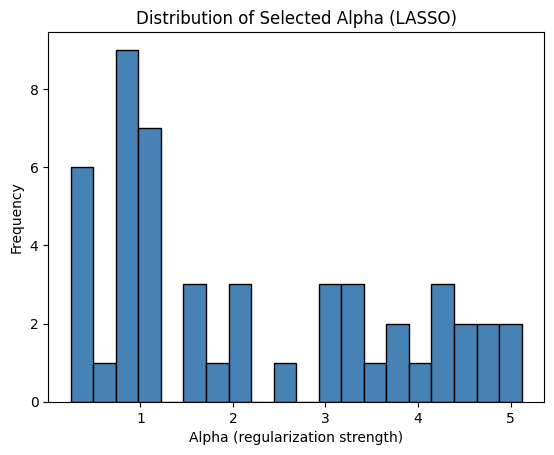

In [55]:
plt.figure()
plt.hist(best_alphas, bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Alpha (regularization strength)")
plt.ylabel("Frequency")
plt.title("Distribution of Selected Alpha (LASSO)")
plt.show()

Here we can see the dist of the sleected features so we can see if the model is stable or not

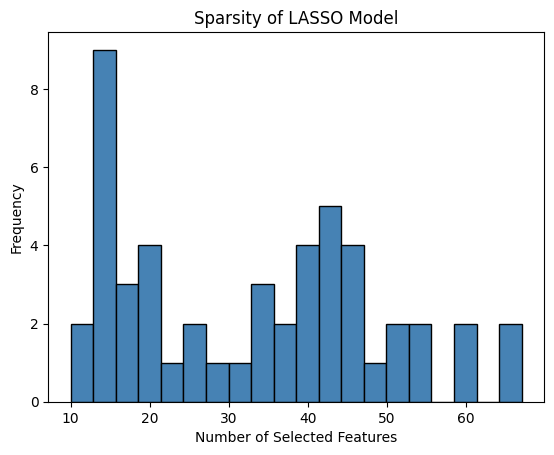

In [56]:
plt.figure()
plt.hist(n_selected_list, bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Number of Selected Features")
plt.ylabel("Frequency")
plt.title("Sparsity of LASSO Model")
plt.show()

here we can see the most frequent features; first 4 always appear

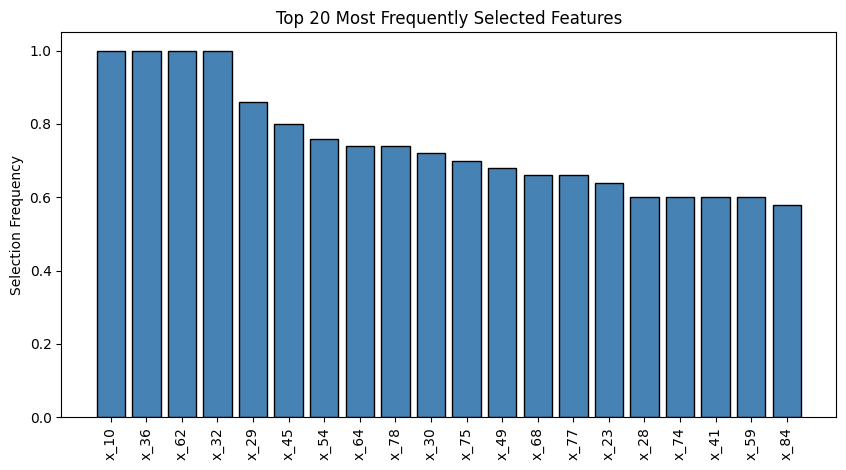

In [57]:
feature_names = X.columns
selection_freq = selection_counts / 50
sorted_idx = np.argsort(selection_freq)[::-1]
top_idx = sorted_idx[:20]

plt.figure(figsize=(10,5))
plt.bar(range(20), selection_freq[top_idx], color='steelblue', edgecolor='black')
plt.xticks(range(20), feature_names[top_idx], rotation=90)
plt.ylabel("Selection Frequency")
plt.title("Top 20 Most Frequently Selected Features")
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
y_centered, mu = centerData(y_class.values)

# select best alpha
lasso_final = LassoCV(cv=5, fit_intercept=False)
lasso_final.fit(X_scaled, y_centered)
best_alpha = lasso_final.alpha_
print(f"Selected alpha: {best_alpha}")

# see how many coefs are not zero
coef_final = lasso_final.coef_ 
non_zero_count = np.sum(coef_final != 0)
print(f"Number of non-zero coefficients: {non_zero_count}")

c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.091e+01, tolerance: 4.601e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Maria\anaconda3\envs\compdata\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.888e+01, tolerance: 4.557e+01
  model = cd_fast.enet_coordinate_descent(


Selected alpha: 3.030592831788761
Number of non-zero coefficients: 23


Alpha chosen by 1 SE rule: 6.529214328167667
Number of non-zero coefficients (1 SE): 9
Non-zero coefficients (1 SE): Index(['x_10', 'x_29', 'x_30', 'x_32', 'x_36', 'x_41', 'x_45', 'x_62', 'x_74'], dtype='str')


Alpha chosen by min CV MSE: 3.390488936049632
Number of non-zero coefficients (min CV MSE): 23


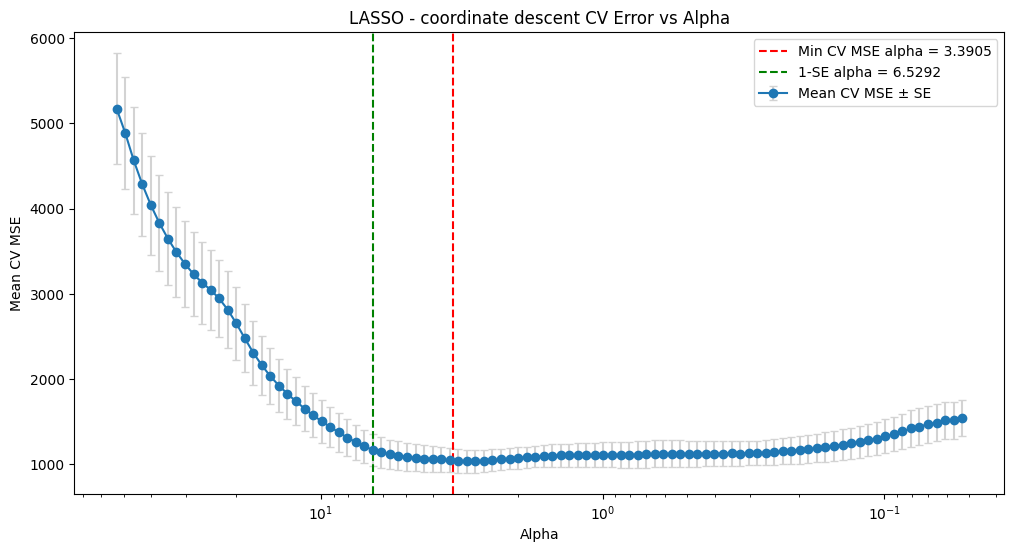

In [66]:
mse_path = lasso_final.mse_path_ 
mse_mean = np.mean(mse_path, axis=1)
mse_std = np.std(mse_path, axis=1) / np.sqrt(mse_path.shape[1])

# find alpha with lower mse mean
min_idx = np.argmin(mse_mean)
min_mse = mse_mean[min_idx]
min_se = mse_std[min_idx]

threshold = min_mse + min_se

# find largest alpha with mse smaller than threshold
alphas = lasso_final.alphas_
one_se_idx = np.where(mse_mean <= threshold)[0] 
alpha_1se = np.max(alphas[one_se_idx]) 

# coefs of 1se alpha
# refit on the full scaled data, coefs are not stored by lassolars cv
lasso_1se = Lasso(alpha=alpha_1se, fit_intercept=False)
lasso_1se.fit(X_scaled, y_centered)
coef_1se = lasso_1se.coef_
non_zero_1se = coef_1se != 0
selected_features = feature_names[non_zero_1se]

print(f"Alpha chosen by 1 SE rule: {alpha_1se}")
print(f"Number of non-zero coefficients (1 SE): {np.sum(non_zero_1se)}")
print(f"Non-zero coefficients (1 SE): {selected_features}")
print("\n")
print(f"Alpha chosen by min CV MSE: {best_alpha}")
print(f"Number of non-zero coefficients (min CV MSE): {non_zero_count}")

plt.figure(figsize=(12,6))
plt.errorbar(alphas, mse_mean, yerr=mse_std, fmt='-o', ecolor='lightgray', capsize=3,label='Mean CV MSE ± SE')
plt.axvline(best_alpha, color='red', linestyle='--',label=f'Min CV MSE alpha = {best_alpha:.4f}')
plt.axvline(alpha_1se, color='green', linestyle='--',label=f'1-SE alpha = {alpha_1se:.4f}')
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LASSO - coordinate descent CV Error vs Alpha")
plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

In [52]:
y_pred_min = X_scaled @ coef_final # alpha_min
mse_train_min = np.sqrt(np.mean((y_pred_min - y_centered)**2))

y_pred_1se = X_scaled @ coef_1se
mse_train_1se = np.sqrt(np.mean((y_pred_1se - y_centered)**2))

print(f"Train MSE (min CV alpha): {mse_train_min:.4f}")
print(f"Train MSE (1 SE alpha): {mse_train_1se:.4f}")

Train MSE (min CV alpha): 24.4650
Train MSE (1 SE alpha): 31.6299


In [72]:
X_scaled.shape

(100, 119)

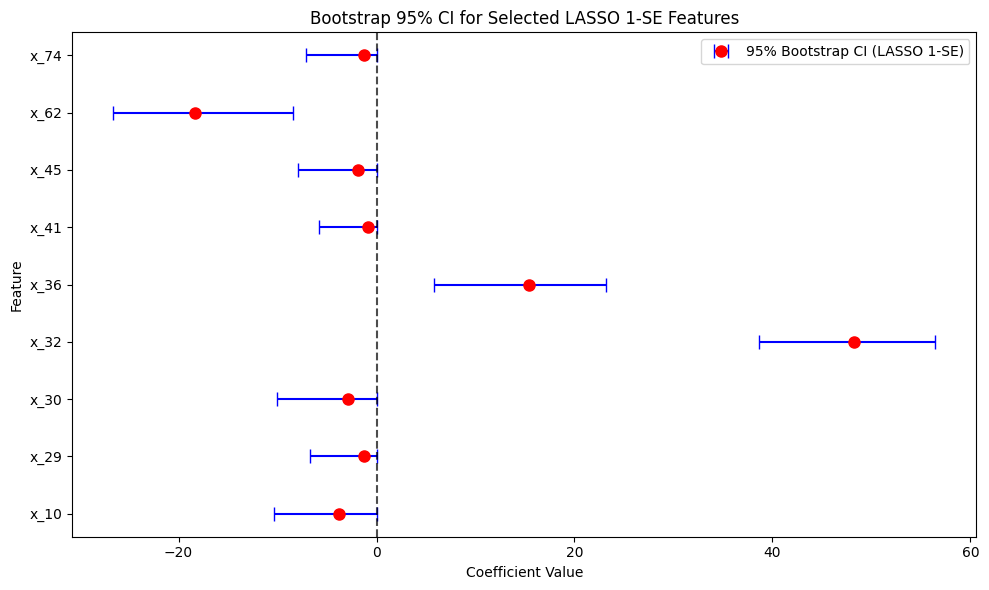

In [ ]:
from sklearn.utils import resample

B = 1000 
N, M = X_scaled.shape
boot_betas = np.zeros((B, M))

for b in range(B):

    # Resample with replacement to simulate new experiments
    X_resamp, y_resamp = resample(X_scaled, y_centered, replace=True, n_samples=N, random_state=b)

    # Fit with 1se alpha
    lasso_model = Lasso(alpha=alpha_1se, fit_intercept=False, max_iter=10000)
    lasso_model.fit(X_resamp, y_resamp)
    boot_betas[b,:] = lasso_model.coef_

# keep only selected features
boot_betas_selected = boot_betas[:, non_zero_1se]
feature_names_selected = feature_names[non_zero_1se]

# Compute median and 95% CI for selected features
means = np.mean(boot_betas_selected, axis=0)
lower_bounds = np.percentile(boot_betas_selected, 2.5, axis=0)
upper_bounds = np.percentile(boot_betas_selected, 97.5, axis=0)

# Error bars
lower_errors = np.maximum(means - lower_bounds, 0)
upper_errors = np.maximum(upper_bounds - means, 0)
errors = np.vstack([lower_errors, upper_errors])

# Plot only selected features
plt.figure(figsize=(10, 6))
plt.errorbar(means, range(len(feature_names_selected)), xerr=errors, fmt='o',
             color="red", ecolor="blue", capsize=5, markersize=8,
             label='95% Bootstrap CI (LASSO 1-SE)')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.yticks(range(len(feature_names_selected)), feature_names_selected)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Bootstrap 95% CI for Selected LASSO 1-SE Features")
plt.legend()
plt.tight_layout()
plt.show()
